# Step 5-1 Recursive Deep Learning Framework

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from keras.models import Sequential, load_model
from keras.layers import Dense, LSTM, Bidirectional, RepeatVector, TimeDistributed, Conv1D, Flatten
from keras.layers import SimpleRNN, Dropout
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from tensorflow.keras import regularizers

import warnings
import os

warnings.filterwarnings("ignore")

In [2]:
# Config
TARGET_VARIABLES = 'co2'
TARGET_PCT_CHANGE = 'co2_pct_change'
SELECTED_COUNTRIES = ['United States', 'China', 'India']
G7_COUNTRIES = ['United States', 'China', 'India', 'Canada', 'France', 'Germany', 'Italy', 'Japan', 'United Kingdom']
G20_COUNTRIES = [
    'United States', 'China', 'Japan', 'Germany', 
    'United Kingdom', 'France', 'Italy', 'Canada',
    'Brazil', 'Russia', 'India', 'Australia', 
    'Mexico', 'Indonesia', 'Turkey', 'Saudi Arabia',
    'South Africa', 'Argentina', 'South Korea'
]

MAX_LAGS = 4
N_STEPS_IN = 5
N_STEPS_OUT = 3
TEST_SIZE = 9

MULTIVARIATE_FEATURES = [
    'gdp',
    'primary_energy_consumption',
    'population',
    'biofuel_share_energy',
    'low_carbon_share_energy',
    'methane',
    'nitrous_oxide'
]

ALL_FEATURES = [TARGET_VARIABLES] + MULTIVARIATE_FEATURES

save_dir = 'data/05_01_results'
os.makedirs(save_dir, exist_ok=True)

models_dir = 'data/03_03_results/saved_models'

### Data Load

In [3]:
# Data load
def load_data(save_dir='data'):
    data_files = {
        'g20_interpolated_df': os.path.join(save_dir, 'g20_interpolated_df.csv'),
        'g20_lag_df': os.path.join(save_dir, 'g20_lag_df.csv')
    }

    dfs = {}
    for name, filepath in data_files.items():
        if os.path.exists(filepath):
            dfs[name] = pd.read_csv(filepath)
            print(f"Loaded {name}: {dfs[name].shape}")
        else:
            print(f"{filepath} not found")
    
    return dfs

In [4]:
data = load_data()
g20_interpolated_df = data['g20_interpolated_df']
g20_lag_df = data['g20_lag_df']
g20_lag_1969_df = g20_lag_df[g20_lag_df['year'] >= 1969].copy()
g20_lag_1969_df = g20_lag_1969_df[g20_lag_1969_df['year'] < 2023]

Loaded g20_interpolated_df: (855, 992)
Loaded g20_lag_df: (3744, 992)


In [5]:
def tts_by_year(interpolated_df, full_df, countries, test_size=TEST_SIZE):
    train_data = {}
    test_data = {}

    for country in countries:
        country_train = interpolated_df[interpolated_df['country'] == country].sort_values('year').copy()

        country_full = full_df[full_df['country'] == country].sort_values('year').copy()
        split_idx = len(country_full) - test_size
        country_test = country_full.iloc[split_idx:].copy()

        train_data[country] = country_train
        test_data[country] = country_test

        print(f"\n{country}:")
        print(f"    Train: {len(country_train)} samples, years {country_train['year'].min()}-{country_train['year'].max()}")
        print(f"    Test:  {len(country_test)} samples, years {country_test['year'].min()}-{country_test['year'].max()}")

    train_df = pd.concat(train_data.values(), ignore_index=True)
    test_df = pd.concat(test_data.values(), ignore_index=True)

    return train_df, test_df

In [6]:
g20_train_df, g20_test_df = tts_by_year(g20_interpolated_df, g20_lag_1969_df, G20_COUNTRIES)


United States:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

China:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

Japan:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

Germany:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

United Kingdom:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

France:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

Italy:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

Canada:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

Brazil:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

Russia:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

India:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

Australia:
    Train: 45 samples, years 1

### Helper Functions

In [7]:
def mase(y_actual, y_pred, period=1):
    mae_forecast = mean_absolute_error(y_actual, y_pred)

    naive_forecast = y_actual[:-period] if period > 0 else y_actual[:-1]
    actual_for_naive = y_actual[period:] if period > 0 else y_actual[1:]

    if len(naive_forecast) == 0:
        return np.nan
    
    mae_naive = mean_absolute_error(actual_for_naive, naive_forecast)

    if mae_naive == 0:
        return 0 if mae_forecast == 0 else np.inf
    
    return mae_forecast / mae_naive

In [8]:
def calculate_pct_change(df, features, max_lags=MAX_LAGS):
    df_copy = df.copy()
    df_copy = df_copy.sort_values(['country', 'year']).reset_index(drop=True)
    pct_change_cols = []

    for feature in features:
        if feature not in df_copy.columns:
            continue

        # Pct change on current values
        lag1_col = f"{feature}_lag1"
        if lag1_col in df_copy.columns:
            df_copy[f"{feature}_pct_change"] = ((df_copy[feature] - df_copy[lag1_col]) / df_copy[lag1_col] * 100)
            pct_change_cols.append(f"{feature}_pct_change")

        # Pct change on lagged values
        for lag in range(1, max_lags):
            lag_col = f"{feature}_lag{lag}"
            prev_lag_col = f"{feature}_lag{lag+1}"
            
            if lag_col in df_copy.columns and prev_lag_col in df_copy.columns:
                df_copy[f"{lag_col}_pct_change"] = ((df_copy[lag_col] - df_copy[prev_lag_col]) / df_copy[prev_lag_col] * 100)
                pct_change_cols.append(f"{lag_col}_pct_change")

        # Lag4 for the first row = 0, then shift lag3_pct by country
        last_lag_col = f"{feature}_lag{max_lags}"
        lag3_pct_col = f"{feature}_lag{max_lags-1}_pct_change"

        if last_lag_col in df_copy.columns and lag3_pct_col in df_copy.columns:
            df_copy[f"{last_lag_col}_pct_change"] = df_copy.groupby('country')[lag3_pct_col].shift(1).fillna(0)
            pct_change_cols.append(f"{last_lag_col}_pct_change")
            
        df_copy = df_copy.replace([np.inf, -np.inf], np.nan)
    
    return df_copy, pct_change_cols

In [9]:
def create_sequences(data, n_steps_in, n_steps_out):
    X, y = [], []

    for i in range(len(data) - n_steps_in - n_steps_out + 1):
        X.append(data[i:i + n_steps_in])
        y.append(data[i + n_steps_in:i + n_steps_in + n_steps_out])

        return np.array(X), np.array(y)

### Preparing train data and scaler

In [10]:
def prepare_train_data(train_df, features, target):
    all_train_pct_data = []
    country_train_info = {}

    for country in train_df['country'].unique():
        country_data = train_df[train_df['country'] == country].sort_values('year').reset_index(drop=True)
        
        country_pct, pct_cols = calculate_pct_change(country_data, features, MAX_LAGS)

        feature_pct_values = []
        for feat in features:
            pct_col = f"{feat}_pct_change"
            if pct_col in country_pct.columns:
                pct_values = country_pct[pct_col].fillna(0).values
                feature_pct_values.append(pct_values)
        
        feature_pct_array = np.column_stack(feature_pct_values)
        all_train_pct_data.append(feature_pct_array)
        
        country_train_info[country] = {
            'pct_values': feature_pct_array,
            'original_values': country_data[target].values,
            'years': country_data['year'].values
        }
    
    return all_train_pct_data, country_train_info

In [11]:
def fit_scaler(all_train_pct_data, features):
    all_train_pct_combined = np.vstack(all_train_pct_data)
    print(f"Combined train data shape: {all_train_pct_combined.shape}")
    
    scaler = StandardScaler()
    scaler.fit(all_train_pct_combined)
    
    for i, feat in enumerate(features):
        print(f"{feat} mean={scaler.mean_[i]:.4f}, std={np.sqrt(scaler.var_[i]):.4f}")
    
    return scaler

In [12]:
g20_train_pct_data, g20_country_train_info = prepare_train_data(g20_train_df, ALL_FEATURES, TARGET_VARIABLES)
scaler = fit_scaler(g20_train_pct_data, ALL_FEATURES)

Combined train data shape: (855, 8)
co2 mean=3.1697, std=6.0995
gdp mean=4.1104, std=3.9942
primary_energy_consumption mean=3.3644, std=4.9041
population mean=1.3660, std=1.1642
biofuel_share_energy mean=13.6640, std=82.8953
low_carbon_share_energy mean=4.3946, std=34.6631
methane mean=0.8311, std=4.7362
nitrous_oxide mean=1.2960, std=7.3238


### Load G20 LSTM model

In [13]:
lstm_model_path = os.path.join(models_dir, 'three_LSTM_model.keras')

if os.path.exists(lstm_model_path):
    original_lstm_model = load_model(lstm_model_path)
    print("LSTM model loaded")
else:
    print("Model not found")

LSTM model loaded


2026-02-12 10:28:25.049846: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-02-12 10:28:25.049879: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-02-12 10:28:25.049883: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2026-02-12 10:28:25.049901: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-12 10:28:25.049912: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [14]:
batch_size = 16
epochs = 100

def build_lstm(input_shape, output_steps=N_STEPS_OUT, hidden=32, dropout=0.0, lr=0.0001, l2=0.001):
    model = Sequential([
        LSTM(hidden, activation='relu', input_shape=input_shape, kernel_regularizer=regularizers.l2(l2)),
        Dropout(dropout),
        Dense(output_steps)
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

In [ ]:
def train_recursive_lstm(train_pct_data, scaler):

    X_train_all = []
    y_train_all = []

    for country_data in train_pct_data:
        scaled_data = scaler.transform(country_data)
        X_seq, y_seq = create_sequences(scaled_data, N_STEPS_IN, N_STEPS_OUT)

        if len(X_seq) > 0:
            X_train_all.append(X_seq)
            # First column (CO2)
            y_train_all.append(y_seq[:, :, 0]) # Shape is (n_samples, 3)

    X_train = np.vstack(X_train_all)
    y_train = np.vstack(y_train_all)

    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")

    input_shape = (X_train.shape[1], X_train.shape[2])
    model = build_lstm(input_shape)

    callbacks = [EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)]

    # Validation not needed
    model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=16,
        callbacks=callbacks,
        verbose=0
    )

    recursive_dir = 'data/05_01_results/saved_models'
    os.makedirs(recursive_dir, exist_ok=True)
    model_path = os.path.join(recursive_dir, 'recursive_lstm_model.keras')
    model.save(model_path)

    return model

In [20]:
recursive_lstm_model = train_recursive_lstm(g20_train_pct_data, scaler)

X_train shape: (19, 5, 8)
y_train shape: (19, 3)


### Recursive Prediction

In [21]:
class RecursivePredictor:
    def __init__(self, model, scaler, n_steps_in=N_STEPS_IN, n_steps_out=N_STEPS_OUT):
        self.model = model
        self.scaler = scaler
        self.n_steps_in = n_steps_in
        self.n_steps_out = n_steps_out
        self.n_features = len(ALL_FEATURES)

    def recursive_forecast(self, X_full_scaled, n_predictions):
        
        predictions_co2_scaled = []
        predicted_co2 = {}

        start_pos = len(X_full_scaled) - n_predictions - self.n_steps_in
        position = start_pos
        iteration = 0

        while len(predictions_co2_scaled) < n_predictions:
            if iteration == 0:
                X_input = X_full_scaled[position:position + self.n_steps_in].copy()
                input_desc = "5 actuals"

            elif iteration == 1:
                X_input = []
                n_actual = 2

                # Append 2 actuals
                for i in range(n_actual):
                    X_input.append(X_full_scaled[position + i])

                # Append 3 predictions
                for i in range(self.n_steps_out):
                    time_idx = position + n_actual + i
                    
                    if time_idx in predicted_co2:
                        # Replace co2 with preds
                        row = X_full_scaled[time_idx].copy()
                        row[0] = predicted_co2[time_idx]
                        X_input.append(row)
                    else:
                        X_input.append(X_full_scaled[time_idx])

                X_input = np.array(X_input)
                input_desc = "2 actuals + 3 preds"

            else:
                X_input = []

                for i in range(self.n_steps_in):
                    time_idx = position + i

                    if time_idx in predicted_co2:
                        row = X_full_scaled[time_idx].copy()
                        row[0] = predicted_co2[time_idx]
                        X_input.append(row)

                    else:
                        X_input.append(X_full_scaled[time_idx])

                X_input = np.array(X_input)
                input_desc = "5 preds"

            print(f"    Input: {input_desc}")

            # Make preds of 3 steps
            X_input_reshaped = X_input.reshape(1, self.n_steps_in, -1)
            pred_co2_scaled = self.model.predict(X_input_reshaped, verbose=0).ravel()

            print(f"    Predicted {len(pred_co2_scaled)} values")

            # Store preds
            for i in range(len(pred_co2_scaled)):
                time_idx = position + self.n_steps_in + i
                predicted_co2[time_idx] = pred_co2_scaled[i]

                if len(predictions_co2_scaled) < n_predictions:
                    predictions_co2_scaled.append(pred_co2_scaled[i])

            print(f"    Total Preds: {len(predictions_co2_scaled)}/{n_predictions}")

            position += self.n_steps_out
            iteration += 1

            if iteration > 5:
                break

        predictions_co2_scaled = np.array(predictions_co2_scaled[:n_predictions])

        return predictions_co2_scaled

In [26]:
def original_lstm_forecast(model, X_ini_scaled, actuals_scaled, n_predictions):
    print(f"\nOriginal LSTM preds: {n_predictions} steps")
    print(f"Initial window shape: {X_ini_scaled.shape}")

    predictions_scaled = []
    curr_window = X_ini_scaled.copy()

    for i in range(n_predictions):
        X_input = curr_window.reshape(1, N_STEPS_IN, -1)

        # CO2 only
        pred_scaled = model.predict(X_input, verbose=0).ravel()
        
        predictions_scaled.append(pred_scaled[0])

        if i < len(actuals_scaled) - 1:
            curr_window = np.vstack([curr_window[1:], actuals_scaled[i + 1].reshape(1, -1)])

    return np.array(predictions_scaled)

In [23]:
def denorm_co2(predictions_co2_scaled, original_values, start_idx, scaler):
    predictions = []

    for i in range(len(predictions_co2_scaled)):
        prev_value = original_values[start_idx + i - 1]

        tmp = np.zeros((1, len(ALL_FEATURES)))
        tmp[0, 0] = predictions_co2_scaled[i]
        pct_change = scaler.inverse_transform(tmp)[0, 0]

        co2_value = prev_value * (1 + pct_change / 100)
        predictions.append(co2_value)

    return np.array(predictions)

In [28]:
def evaluate_strat(original_model, recursive_model, train_df, test_df, scaler):
    
    all_results = {}
    
    for country in SELECTED_COUNTRIES:
        print(f"{country.upper()}")

        train_country = train_df[train_df['country'] == country].sort_values('year').reset_index(drop=True)
        test_country = test_df[test_df['country'] == country].sort_values('year').reset_index(drop=True)
        
        combined_data = pd.concat([train_country, test_country], ignore_index=True)
        combined_pct, _ = calculate_pct_change(combined_data, ALL_FEATURES, MAX_LAGS)
        
        pct_change_values = []
        for feat in ALL_FEATURES:
            pct_col = f"{feat}_pct_change"
            if pct_col in combined_pct.columns:
                pct_values = combined_pct[pct_col].fillna(0).values
                pct_change_values.append(pct_values)
        
        stacked_combined_pct = np.column_stack(pct_change_values)
        combined_scaled = scaler.transform(stacked_combined_pct)
        original_values = combined_data[TARGET_VARIABLES].values
        
        test_start_idx = len(original_values) - TEST_SIZE
        X_initial = combined_scaled[test_start_idx - N_STEPS_IN:test_start_idx]
        test_scaled = combined_scaled[test_start_idx:]

        # Original LSTM
        original_preds_scaled = original_lstm_forecast(original_model, X_initial, test_scaled, TEST_SIZE)
        original_preds = denorm_co2(original_preds_scaled, original_values, test_start_idx, scaler)
        
        # Recursive LSTM
        predictor = RecursivePredictor(recursive_model, scaler)
        recursive_preds_scaled = predictor.recursive_forecast(combined_scaled, TEST_SIZE)
        recursive_preds = denorm_co2(recursive_preds_scaled, original_values, test_start_idx, scaler)
        
        actual_test = original_values[-TEST_SIZE:]
        test_years = test_country['year'].values

        # Metrics
        original_rmse = np.sqrt(mean_squared_error(actual_test, original_preds))
        original_mase = mase(actual_test, original_preds)
        recursive_rmse = np.sqrt(mean_squared_error(actual_test, recursive_preds))
        recursive_mase = mase(actual_test, recursive_preds)

        print(f"  Original  - RMSE: {original_rmse:.4f}, MASE: {original_mase:.4f}")
        print(f"  Recursive - RMSE: {recursive_rmse:.4f}, MASE: {recursive_mase:.4f}")
        
        all_results[country] = {
            'test_years': test_years,
            'actual': actual_test,
            'original_forecast': original_preds,
            'recursive_forecast': recursive_preds,
            'original_rmse': original_rmse,
            'original_mase': original_mase,
            'recursive_rmse': recursive_rmse,
            'recursive_mase': recursive_mase
        }

        predictions_df = pd.DataFrame({
            'year': test_years,
            'actual': actual_test,
            'original_forecast': original_preds,
            'recursive_forecast': recursive_preds
        })

        # Save csv ...

    return all_results

In [29]:
results = evaluate_strat(original_lstm_model, recursive_lstm_model, g20_train_df, g20_test_df, scaler)

UNITED STATES

Original LSTM preds: 9 steps
Initial window shape: (5, 8)
    Input: 5 actuals
    Predicted 3 values
    Total Preds: 3/9
    Input: 2 actuals + 3 preds
    Predicted 3 values
    Total Preds: 6/9
    Input: 5 preds
    Predicted 3 values
    Total Preds: 9/9
  Original  - RMSE: 229.0075, MASE: 0.8808
  Recursive - RMSE: 299.3638, MASE: 1.2476
CHINA

Original LSTM preds: 9 steps
Initial window shape: (5, 8)
    Input: 5 actuals
    Predicted 3 values
    Total Preds: 3/9
    Input: 2 actuals + 3 preds
    Predicted 3 values
    Total Preds: 6/9
    Input: 5 preds
    Predicted 3 values
    Total Preds: 9/9
  Original  - RMSE: 261.4996, MASE: 0.9092
  Recursive - RMSE: 331.2103, MASE: 1.0941
INDIA

Original LSTM preds: 9 steps
Initial window shape: (5, 8)
    Input: 5 actuals
    Predicted 3 values
    Total Preds: 3/9
    Input: 2 actuals + 3 preds
    Predicted 3 values
    Total Preds: 6/9
    Input: 5 preds
    Predicted 3 values
    Total Preds: 9/9
  Original  - RM

### Plot

In [30]:
def plot_comparison(results, train_df):
    for country in SELECTED_COUNTRIES:
        result = results[country]
        train_country = train_df[train_df['country'] == country].sort_values('year')
        
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))

        ax.plot(train_country['year'], train_country[TARGET_VARIABLES], 
                'gray', linewidth=2, label='Training', alpha=0.6)

        test_years = result['test_years']
        ax.plot(test_years, result['actual'], 'k-', linewidth=2, label='Actual', marker='o', markersize=5)
        ax.plot(test_years, result['original_forecast'], 'b--', linewidth=2, label='Original (1-step)', marker='^', markersize=5)
        ax.plot(test_years, result['recursive_forecast'], 'r--', linewidth=2, label='Recursive (3-step)', marker='s', markersize=5)

        # Metrics
        metrics_text = f"Original:  RMSE={result['original_rmse']:.2f}, MASE={result['original_mase']:.4f}\n"
        metrics_text += f"Recursive: RMSE={result['recursive_rmse']:.2f}, MASE={result['recursive_mase']:.4f}"
        
        props = dict(boxstyle='round', facecolor='lightblue', alpha=0.7)
        ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes, fontsize=10, 
                verticalalignment='top', bbox=props, fontweight='bold')
        
        ax.set_title(f'{country}: Original vs Recursive LSTM', fontsize=14, fontweight='bold')
        ax.set_xlabel('Year', fontsize=11)
        ax.set_ylabel('CO2 Emissions (Mt)', fontsize=11)
        ax.legend(loc='best', fontsize=10)
        
        plt.tight_layout()


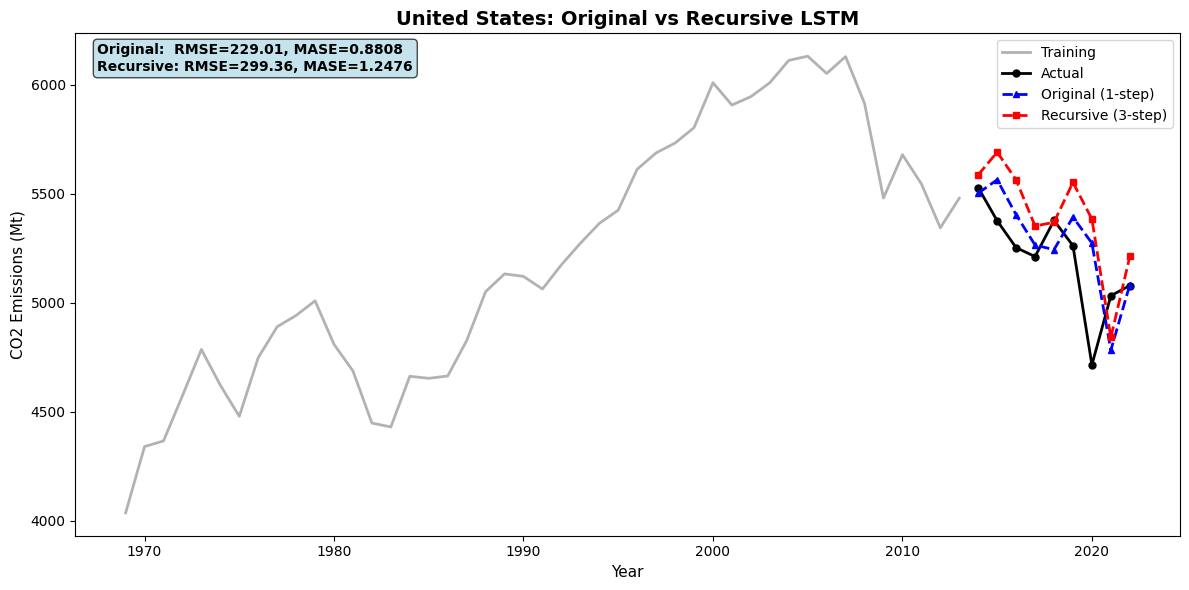

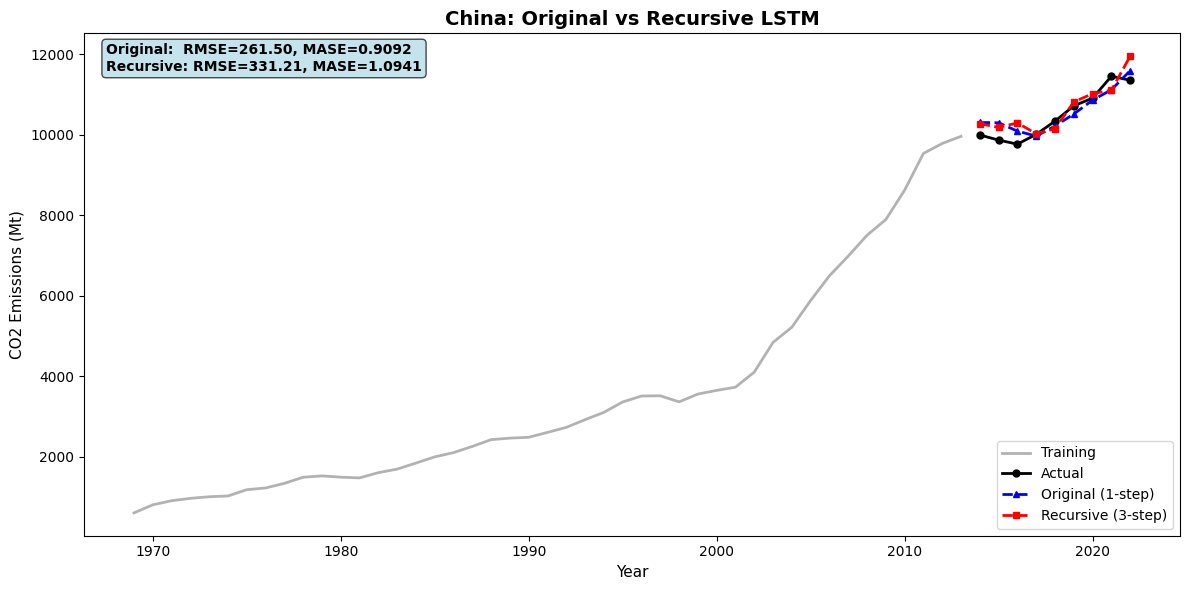

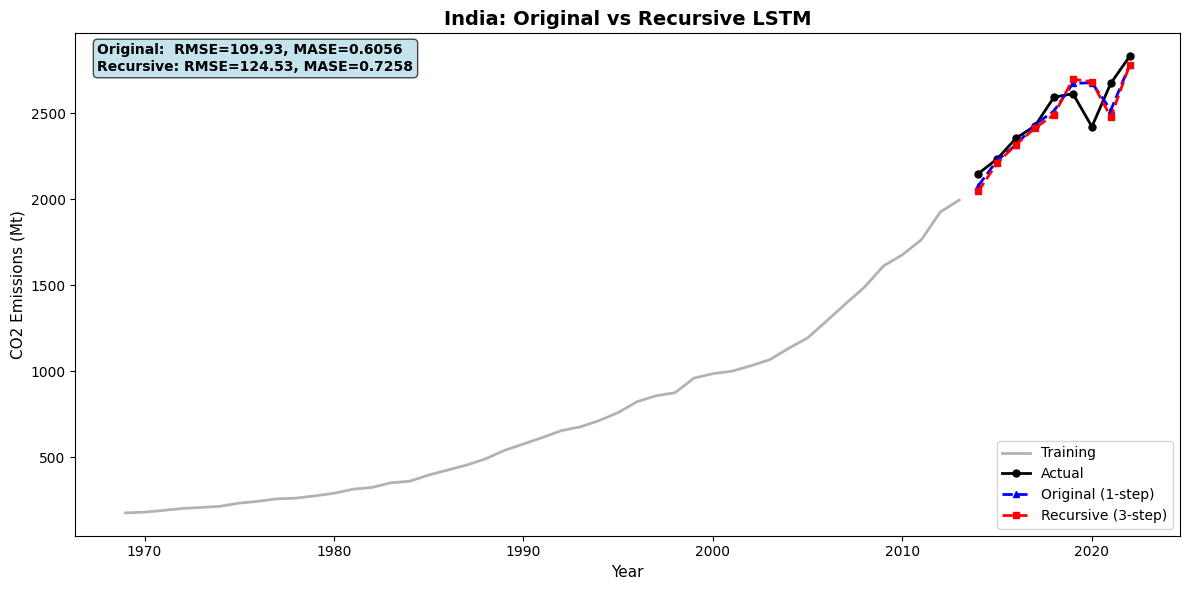

In [31]:
plot_comparison(results, g20_train_df)

In [ ]:
for country in SELECTED_COUNTRIES:
    result = results[country]
    print(f"\n{country}:")
    print(f"  Original:  RMSE={result['original_rmse']:.4f}, MASE={result['original_mase']:.4f}")
    print(f"  Recursive: RMSE={result['recursive_rmse']:.4f}, MASE={result['recursive_mase']:.4f}")


United States:
  Original:  RMSE=229.0075, MASE=0.8808
  Recursive: RMSE=299.3638, MASE=1.2476

China:
  Original:  RMSE=261.4996, MASE=0.9092
  Recursive: RMSE=331.2103, MASE=1.0941

India:
  Original:  RMSE=109.9273, MASE=0.6056
  Recursive: RMSE=124.5260, MASE=0.7258


### 10 year ahead forecast